In [1]:
import requests
import json
import time

url = "https://datahub.uba.de/server/rest/services/VeLa/LK/MapServer/4110"
query_url = f"{url}/query"

# Hole alle Objekt-IDs
params = {
    "where": "1=1",
    "returnIdsOnly": "true",
    "f": "json"
}
ids = requests.get(query_url, params=params).json()["objectIds"]

features = []
step = 500  # Server-Limit ist meist 1000, hier sicherheitshalber 500

for i in range(0, len(ids), step):
    oid_subset = ids[i:i+step]
    params = {
        "objectIds": ",".join(map(str, oid_subset)),
        "f": "geojson",
        "outFields": "*",
        "returnGeometry": "true"
    }
    r = requests.get(query_url, params=params)
    features.extend(r.json()["features"])
    print(f"{i+step} von {len(ids)} geladen…")
    time.sleep(1)  # höflicher Wait

# Speichern
with open("LK_HLQ_road_Den.geojson", "w", encoding="utf-8") as f:
    json.dump({"type": "FeatureCollection", "features": features}, f)


ConnectionError: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))

In [2]:
import requests
import time
import json
import geopandas as gpd
from requests.adapters import HTTPAdapter, Retry

url = "https://datahub.uba.de/server/rest/services/VeLa/LK/MapServer/4110"
query_url = f"{url}/query"

# Session mit Retry-Logik
session = requests.Session()
retries = Retry(total=5, backoff_factor=2, status_forcelist=[500, 502, 503, 504])
adapter = HTTPAdapter(max_retries=retries)
session.mount("http://", adapter)
session.mount("https://", adapter)

# Alle ObjectIDs abfragen
print("Lade ObjectIDs…")
ids = session.get(query_url, params={
    "where": "1=1",
    "returnIdsOnly": "true",
    "f": "json"
}, timeout=30).json()["objectIds"]

print(f"{len(ids)} ObjectIDs gefunden.")

features = []
step = 250  # kleineres Paging

for i in range(0, len(ids), step):
    subset = ids[i:i + step]
    try:
        r = session.get(query_url, params={
            "objectIds": ",".join(map(str, subset)),
            "f": "geojson",
            "outFields": "*",
            "returnGeometry": "true"
        }, timeout=60)
        r.raise_for_status()
        data = r.json()
        features.extend(data.get("features", []))
        print(f"{i + step} von {len(ids)} geladen…")
    except Exception as e:
        print(f"Fehler bei Batch {i}-{i+step}: {e}")
        continue
    time.sleep(1)

# GeoDataFrame erstellen und speichern
print("Speichern als GeoParquet…")
gdf = gpd.GeoDataFrame.from_features(features)
gdf.set_crs(epsg=25833, inplace=True)  # evtl. anpassen je nach Layer

# als GeoParquet speichern
gdf.to_parquet("LK_HLQ_road_Den.parquet", index=False)
print("Fertig!")


Lade ObjectIDs…
345 ObjectIDs gefunden.
Fehler bei Batch 0-250: HTTPSConnectionPool(host='datahub.uba.de', port=443): Max retries exceeded with url: /server/rest/services/VeLa/LK/MapServer/4110/query?objectIds=1%2C2%2C3%2C4%2C5%2C6%2C7%2C8%2C9%2C10%2C11%2C12%2C13%2C14%2C15%2C16%2C17%2C18%2C19%2C20%2C21%2C22%2C23%2C24%2C25%2C26%2C27%2C28%2C29%2C30%2C31%2C32%2C33%2C34%2C35%2C36%2C37%2C38%2C39%2C40%2C41%2C42%2C43%2C44%2C45%2C46%2C47%2C48%2C49%2C50%2C51%2C52%2C53%2C54%2C55%2C56%2C57%2C58%2C59%2C60%2C61%2C62%2C63%2C64%2C65%2C66%2C67%2C68%2C69%2C70%2C71%2C72%2C73%2C74%2C75%2C76%2C77%2C78%2C79%2C80%2C81%2C82%2C83%2C84%2C85%2C86%2C87%2C88%2C89%2C90%2C91%2C92%2C93%2C94%2C95%2C96%2C97%2C98%2C99%2C100%2C101%2C102%2C103%2C104%2C105%2C106%2C107%2C108%2C109%2C110%2C111%2C112%2C113%2C114%2C115%2C116%2C117%2C118%2C119%2C120%2C121%2C122%2C123%2C124%2C125%2C126%2C127%2C128%2C129%2C130%2C131%2C132%2C133%2C134%2C135%2C136%2C137%2C138%2C139%2C140%2C141%2C142%2C143%2C144%2C145%2C146%2C147%2C148%2C149%2C150%

KeyboardInterrupt: 

[]

In [ ]:
# OBJECTID-Spanne vorher automatisch bestimmen

r = requests.get(query_url, params={
    "where": "1=1",
    "f": "json",
    "outStatistics": json.dumps([{
        "statisticType": "max",
        "onStatisticField": "OBJECTID",
        "outStatisticFieldName": "max_id"
    }])
})
max_oid = int(r.json()["features"][0]["attributes"]["max_id"]) + 1


In [4]:
import requests
import time
import geopandas as gpd

url = "https://datahub.uba.de/server/rest/services/VeLa/LK/MapServer/4110"
query_url = f"{url}/query"

step = 100
start_oid = 0
max_oid = 345  # wenn du das vorher weißt – sonst erst abrufen (s.u.)

features = []

for i in range(start_oid, max_oid, step):
    where_clause = f"OBJECTID >= {i} AND OBJECTID < {i + step}"
    print(f"Lade: {where_clause}")
    params = {
        "where": where_clause,
        "f": "geojson",
        "outFields": "*",
        "returnGeometry": "true"
    }
    try:
        r = requests.get(query_url, params=params, timeout=60)
        r.raise_for_status()
        data = r.json()
        features.extend(data.get("features", []))
    except Exception as e:
        print(f"Fehler bei OBJECTID {i}-{i+step}: {e}")
        continue
    time.sleep(1)

# GeoDataFrame & Export
gdf = gpd.GeoDataFrame.from_features(features)
gdf.set_crs(epsg=25833, inplace=True)  # ggf. anpassen
gdf.to_parquet("LK_HLQ_road_Den.parquet", index=False)
print("Fertig.")


Lade: OBJECTID >= 0 AND OBJECTID < 100
Fehler bei OBJECTID 0-100: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
Lade: OBJECTID >= 100 AND OBJECTID < 200
Fehler bei OBJECTID 100-200: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
Lade: OBJECTID >= 200 AND OBJECTID < 300


KeyboardInterrupt: 

In [5]:
import requests
import time
import geopandas as gpd
from random import uniform

query_url = "https://datahub.uba.de/server/rest/services/VeLa/LK/MapServer/4110/query"
step = 10
start_oid = 0
max_oid = 350  # oder per Statistik vorherholen
features = []

def download_batch(start, end, retries=3):
    where = f"OBJECTID >= {start} AND OBJECTID < {end}"
    for attempt in range(retries):
        try:
            print(f"Lade: {where} (Versuch {attempt+1})")
            r = requests.get(query_url, params={
                "where": where,
                "f": "geojson",
                "outFields": "*",
                "returnGeometry": "true"
            }, timeout=90)
            r.raise_for_status()
            return r.json().get("features", [])
        except Exception as e:
            print(f"Fehler bei {where}: {e}")
            time.sleep(2 * (attempt + 1) + uniform(0.1, 0.5))  # Exponential Backoff
    print(f"❌ Überspringe {where} nach {retries} Fehlversuchen.")
    return []

for i in range(start_oid, max_oid, step):
    feats = download_batch(i, i + step)
    features.extend(feats)
    time.sleep(uniform(0.5, 1.5))  # kleiner Pause zwischen den Anfragen

print(f"Anzahl Features geladen: {len(features)}")

# Export
gdf = gpd.GeoDataFrame.from_features(features)
gdf.set_crs(epsg=25833, inplace=True)
gdf.to_parquet("LK_HLQ_road_Den.parquet", index=False)
print("✅ Export abgeschlossen.")


Lade: OBJECTID >= 0 AND OBJECTID < 10 (Versuch 1)
Fehler bei OBJECTID >= 0 AND OBJECTID < 10: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
Lade: OBJECTID >= 0 AND OBJECTID < 10 (Versuch 2)


KeyboardInterrupt: 

In [25]:
import requests
import os
import time
from random import uniform

# Setup
layer = 4110
step = 1  # Anzahl OBJECTIDs pro Anfrage
start_oid = 0
#max_oid = 5 #500  # ggf. vorher per Statistik abfragen
out_dir = f"layer_{layer}_geojson"
os.makedirs(out_dir, exist_ok=True)

base_url = f"https://datahub.uba.de/server/rest/services/VeLa/LK/MapServer/{layer}/query"


# OBJECTID-Spanne vorher automatisch bestimmen

r = requests.get(base_url, params={
    "where": "1=1",
    "f": "json",
    "outStatistics": json.dumps([{
        "statisticType": "max",
        "onStatisticField": "OBJECTID",
        "outStatisticFieldName": "max_id"
    }])
})
max_oid = int(r.json()["features"][0]["attributes"]["max_id"]) + 1

max_oid

346

In [26]:


def download_geojson_chunk(start, end):
    where = f"OBJECTID >= {start} AND OBJECTID < {end}"
    params = {
        "where": where,
        # "f": "pbf",
            "f": "geojson",  # statt "pbf"
        "outFields": "*",
        "returnGeometry": "true"
    }
    try:
        r = requests.get(base_url, params=params, timeout=60)
        r.raise_for_status()
        out_path = os.path.join(out_dir, f"chunk_{start}_{end}.geojson")
        with open(out_path, "wb") as f:
            f.write(r.content)
        print(f"✅ {where} gespeichert als {out_path}")
    except Exception as e:
        print(f"❌ Fehler bei {where}: {e}")

# Haupt-Loop
for oid in range(start_oid, max_oid, step):
    download_geojson_chunk(oid, oid + step)
    time.sleep(uniform(0.5, 1.0))  # höfliche Pause


✅ OBJECTID >= 0 AND OBJECTID < 1 gespeichert als layer_4110_geojson/chunk_0_1.geojson
✅ OBJECTID >= 1 AND OBJECTID < 2 gespeichert als layer_4110_geojson/chunk_1_2.geojson
✅ OBJECTID >= 2 AND OBJECTID < 3 gespeichert als layer_4110_geojson/chunk_2_3.geojson
✅ OBJECTID >= 3 AND OBJECTID < 4 gespeichert als layer_4110_geojson/chunk_3_4.geojson
✅ OBJECTID >= 4 AND OBJECTID < 5 gespeichert als layer_4110_geojson/chunk_4_5.geojson
✅ OBJECTID >= 5 AND OBJECTID < 6 gespeichert als layer_4110_geojson/chunk_5_6.geojson
✅ OBJECTID >= 6 AND OBJECTID < 7 gespeichert als layer_4110_geojson/chunk_6_7.geojson
✅ OBJECTID >= 7 AND OBJECTID < 8 gespeichert als layer_4110_geojson/chunk_7_8.geojson
✅ OBJECTID >= 8 AND OBJECTID < 9 gespeichert als layer_4110_geojson/chunk_8_9.geojson
✅ OBJECTID >= 9 AND OBJECTID < 10 gespeichert als layer_4110_geojson/chunk_9_10.geojson
✅ OBJECTID >= 10 AND OBJECTID < 11 gespeichert als layer_4110_geojson/chunk_10_11.geojson
✅ OBJECTID >= 11 AND OBJECTID < 12 gespeichert a

In [15]:
!ogrinfo -al layer_4110_geojson/chunk_0_1.geojson

INFO: Open of `layer_4110_geojson/chunk_0_1.geojson'
      using driver `GeoJSON' successful.

Layer name: chunk_0_1
Geometry: Unknown (any)
Feature Count: 0
Layer SRS WKT:
GEOGCRS["WGS 84",
    DATUM["World Geodetic System 1984",
        ELLIPSOID["WGS 84",6378137,298.257223563,
            LENGTHUNIT["metre",1]]],
    PRIMEM["Greenwich",0,
        ANGLEUNIT["degree",0.0174532925199433]],
    CS[ellipsoidal,2],
        AXIS["geodetic latitude (Lat)",north,
            ORDER[1],
            ANGLEUNIT["degree",0.0174532925199433]],
        AXIS["geodetic longitude (Lon)",east,
            ORDER[2],
            ANGLEUNIT["degree",0.0174532925199433]],
    ID["EPSG",4326]]
Data axis to CRS axis mapping: 2,1


In [19]:
import os
os.environ["OGR_GEOJSON_MAX_OBJ_SIZE"] = "800"  # in MB (z. B. 200 MB)

In [27]:
import geopandas as gpd
import os
import pandas as pd

folder = "layer_4110_geojson"
files = sorted([f for f in os.listdir(folder) if f.endswith(".geojson")])

gdfs = []

for file in files:
    path = os.path.join(folder, file)
    try:
        gdf = gpd.read_file(path)
        gdfs.append(gdf)
    except Exception as e:
        print(f"❌ Error reading {file}: {e}")

# Merge all chunks
full_gdf = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True))

# Set CRS if not already present
if full_gdf.crs is None:
    full_gdf.set_crs(epsg=25833, inplace=True)  # or use correct CRS if different

# Show summary
print(full_gdf.info())
print(full_gdf.head())


❌ Error reading chunk_342_343.geojson: 'layer_4110_geojson/chunk_342_343.geojson' not recognized as being in a supported file format.; It might help to specify the correct driver explicitly by prefixing the file path with '<DRIVER>:', e.g. 'CSV:path'.
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 323 entries, 0 to 322
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   geometry         323 non-null    geometry
 1   OBJECTID         323 non-null    float64 
 2   id               323 non-null    float64 
 3   Lärmpegelklasse  323 non-null    object  
 4   source           323 non-null    object  
 5   measureTim       323 non-null    object  
 6   measureT_1       323 non-null    object  
 7   Shape_Length     323 non-null    float64 
 8   Shape_Area       323 non-null    float64 
dtypes: float64(4), geometry(1), object(4)
memory usage: 22.8+ KB
None
                                            geom

In [28]:
full_gdf

,geometry,OBJECTID,id,Lärmpegelklasse,source,measureTim,measureT_1,Shape_Length,Shape_Area
0,"MULTIPOLYGON (((8.50294 50.08582, 8.50294 50.0...",100.0,170100005.0,Lden5559,majorRoadsIncludingAgglomeration,,,3.587244e+06,1.077876e+08
1,"MULTIPOLYGON (((8.19685 50.04457, 8.19683 50.0...",101.0,170200001.0,LdenGreaterThan75,majorRoadsIncludingAgglomeration,,,4.723668e+05,1.983071e+07
2,"MULTIPOLYGON (((8.16961 50.04308, 8.16961 50.0...",102.0,170200002.0,Lden6569,majorRoadsIncludingAgglomeration,,,1.491054e+06,4.374699e+07
3,"MULTIPOLYGON (((8.16971 50.04277, 8.16969 50.0...",103.0,170200003.0,Lden6064,majorRoadsIncludingAgglomeration,,,1.851847e+06,6.603509e+07
4,"MULTIPOLYGON (((8.16947 50.04313, 8.16946 50.0...",104.0,170200004.0,Lden7074,majorRoadsIncludingAgglomeration,,,1.166934e+06,2.656910e+07
...,...,...,...,...,...,...,...,...,...
318,"MULTIPOLYGON (((8.52035 50.03619, 8.52035 50.0...",96.0,170100001.0,LdenGreaterThan75,majorRoadsIncludingAgglomeration,,,8.138433e+05,4.242800e+07
319,"MULTIPOLYGON (((8.48694 50.08919, 8.48695 50.0...",97.0,170100002.0,Lden6569,majorRoadsIncludingAgglomeration,,,2.185452e+06,8.512491e+07
320,"MULTIPOLYGON (((8.48915 50.09233, 8.48915 50.0...",98.0,170100003.0,Lden6064,majorRoadsIncludingAgglomeration,,,2.626765e+06,9.883946e+07
321,"MULTIPOLYGON (((8.48826 50.08489, 8.48826 50.0...",99.0,170100004.0,Lden7074,majorRoadsIncludingAgglomeration,,,1.851789e+06,5.585522e+07


In [29]:
full_gdf.to_parquet("LK_HLQ_road_Den.parquet", index=False)


<Axes: >

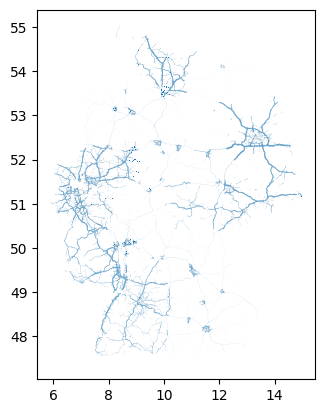

In [30]:
full_gdf.plot()

<Axes: >

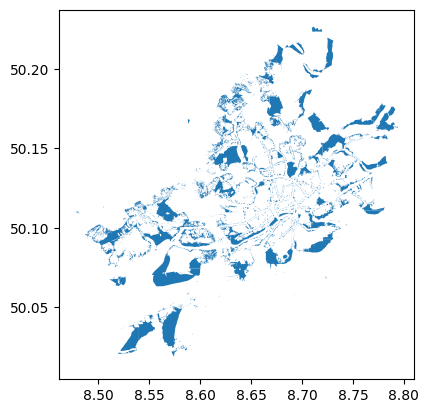

In [31]:
full_gdf[:1].plot()

In [32]:
full_gdf_sample=full_gdf[:1].copy()

In [34]:
full_gdf_sample=full_gdf_sample.to_crs(25833)

In [39]:
import geopandas as gpd
from shapely.geometry import box

def create_grid(bounds, dx, dy):
    minx, miny, maxx, maxy = bounds
    grid_cells = []
    x = minx
    while x < maxx:
        y = miny
        while y < maxy:
            grid_cells.append(box(x, y, x+dx, y+dy))
            y += dy
        x += dx
    return gpd.GeoDataFrame(geometry=grid_cells, crs="EPSG:25833")

# Lade große Polygone
#gdf = gpd.read_file("LK_HLQ_road_Den.parquet")
grid = create_grid(full_gdf_sample.total_bounds, 10000, 10000)  # 10x10 km
cut = gpd.overlay(grid, full_gdf_sample, how='intersection')
#cut.to_file("cut_polygons.geojson")


In [40]:
cut

,OBJECTID,id,Lärmpegelklasse,source,measureTim,measureT_1,Shape_Length,Shape_Area,geometry
0,100.0,170100005.0,Lden5559,majorRoadsIncludingAgglomeration,,,3.587244e+06,1.077876e+08,"MULTIPOLYGON (((35090.538 5568829.176, 35093.5..."
1,100.0,170100005.0,Lden5559,majorRoadsIncludingAgglomeration,,,3.587244e+06,1.077876e+08,"MULTIPOLYGON (((35440.685 5570139.78, 35440.75..."
2,100.0,170100005.0,Lden5559,majorRoadsIncludingAgglomeration,,,3.587244e+06,1.077876e+08,"MULTIPOLYGON (((44106.113 5565513.143, 44110.1..."
3,100.0,170100005.0,Lden5559,majorRoadsIncludingAgglomeration,,,3.587244e+06,1.077876e+08,"MULTIPOLYGON (((44032.009 5570156.866, 44033.0..."
4,100.0,170100005.0,Lden5559,majorRoadsIncludingAgglomeration,,,3.587244e+06,1.077876e+08,"MULTIPOLYGON (((47885.195 5580150.119, 47885.1..."
5,100.0,170100005.0,Lden5559,majorRoadsIncludingAgglomeration,,,3.587244e+06,1.077876e+08,"MULTIPOLYGON (((54129.779 5569546.507, 54128.7..."
6,100.0,170100005.0,Lden5559,majorRoadsIncludingAgglomeration,,,3.587244e+06,1.077876e+08,"MULTIPOLYGON (((53824.922 5570143.339, 53824.8..."


<Axes: >

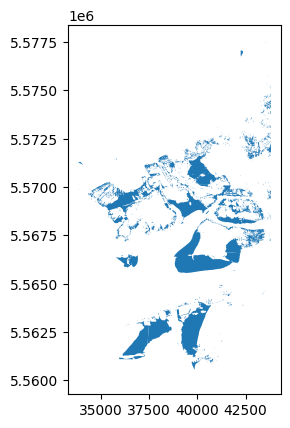

In [42]:
cut[:2].plot()

In [ ]:
import geopandas as gpd
from shapely.geometry import box
import pandas as pd

def create_grid(bounds, dx, dy):
    minx, miny, maxx, maxy = bounds
    grid_cells = []
    x = minx
    while x < maxx:
        y = miny
        while y < maxy:
            grid_cells.append(box(x, y, x + dx, y + dy))
            y += dy
        x += dx
    return gpd.GeoDataFrame(geometry=grid_cells, crs="EPSG:25833")



gdf_cleaned = full_gdf_sample.copy()
gdf_cleaned["geometry"] = gdf_cleaned["geometry"].buffer(0)

# 2. Create a grid, e.g. 10km × 10km
grid = create_grid(gdf_cleaned.total_bounds, 2000, 2000)

# 3. Perform tile-wise cutting
cut_parts = []
for cell in grid.geometry:
    matches = gdf_cleaned[gdf_cleaned.intersects(cell)]
    if not matches.empty:
        clipped = matches.copy()
        clipped["geometry"] = clipped["geometry"].intersection(cell)
        cut_parts.append(clipped)

# 4. Combine cut parts
cut_gdf = gpd.GeoDataFrame(pd.concat(cut_parts, ignore_index=True), crs=gdf_cleaned.crs)




<Axes: >

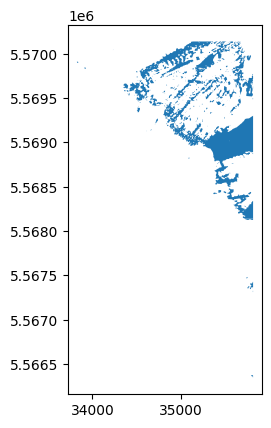

In [55]:
cut_gdf[:2].plot()

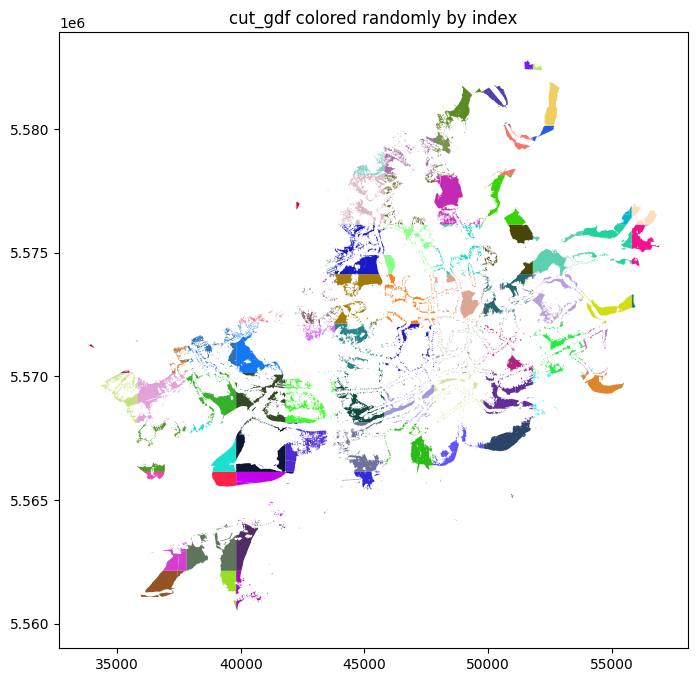

In [56]:
import numpy as np

import matplotlib.pyplot as plt

# Generate a random color for each row
num_features = len(cut_gdf)
colors = np.random.rand(num_features, 3)

ax = cut_gdf.plot(color=colors, figsize=(10, 8))
plt.title("cut_gdf colored randomly by index")
plt.show()

In [57]:
import geopandas as gpd
from shapely.geometry import box
import pandas as pd

def create_grid(bounds, dx, dy):
    minx, miny, maxx, maxy = bounds
    grid_cells = []
    x = minx
    while x < maxx:
        y = miny
        while y < maxy:
            grid_cells.append(box(x, y, x + dx, y + dy))
            y += dy
        x += dx
    return gpd.GeoDataFrame(geometry=grid_cells, crs="EPSG:25833")



gdf_cleaned = full_gdf.copy()
gdf_cleaned["geometry"] = gdf_cleaned["geometry"].buffer(0)

# 2. Create a grid, e.g. 10km × 10km
grid = create_grid(gdf_cleaned.total_bounds, 2000, 2000)

# 3. Perform tile-wise cutting
cut_parts = []
for cell in grid.geometry:
    matches = gdf_cleaned[gdf_cleaned.intersects(cell)]
    if not matches.empty:
        clipped = matches.copy()
        clipped["geometry"] = clipped["geometry"].intersection(cell)
        cut_parts.append(clipped)

# 4. Combine cut parts
cut_gdf = gpd.GeoDataFrame(pd.concat(cut_parts, ignore_index=True), crs=gdf_cleaned.crs)

In [58]:
cut_gdf

,geometry,OBJECTID,id,Lärmpegelklasse,source,measureTim,measureT_1,Shape_Length,Shape_Area
0,"MULTIPOLYGON (((8.77303 50.16328, 8.77305 50.1...",100.0,170100005.0,Lden5559,majorRoadsIncludingAgglomeration,,,3.587244e+06,1.077876e+08
1,"MULTIPOLYGON (((8.38127 50.04685, 8.38126 50.0...",101.0,170200001.0,LdenGreaterThan75,majorRoadsIncludingAgglomeration,,,4.723668e+05,1.983071e+07
2,"MULTIPOLYGON (((8.37078 50.0761, 8.37078 50.07...",102.0,170200002.0,Lden6569,majorRoadsIncludingAgglomeration,,,1.491054e+06,4.374699e+07
3,"MULTIPOLYGON (((8.37362 50.07596, 8.3736 50.07...",103.0,170200003.0,Lden6064,majorRoadsIncludingAgglomeration,,,1.851847e+06,6.603509e+07
4,"MULTIPOLYGON (((8.37955 50.04822, 8.37955 50.0...",104.0,170200004.0,Lden7074,majorRoadsIncludingAgglomeration,,,1.166934e+06,2.656910e+07
...,...,...,...,...,...,...,...,...,...
318,"MULTIPOLYGON (((8.77592 50.15866, 8.77588 50.1...",96.0,170100001.0,LdenGreaterThan75,majorRoadsIncludingAgglomeration,,,8.138433e+05,4.242800e+07
319,"MULTIPOLYGON (((8.76753 50.15922, 8.76752 50.1...",97.0,170100002.0,Lden6569,majorRoadsIncludingAgglomeration,,,2.185452e+06,8.512491e+07
320,"MULTIPOLYGON (((8.78748 50.16057, 8.78748 50.1...",98.0,170100003.0,Lden6064,majorRoadsIncludingAgglomeration,,,2.626765e+06,9.883946e+07
321,"MULTIPOLYGON (((8.78741 50.15986, 8.7873 50.15...",99.0,170100004.0,Lden7074,majorRoadsIncludingAgglomeration,,,1.851789e+06,5.585522e+07


In [59]:
cut_gdf.to_parquet("LK_HLQ_road_Den_cut2km.parquet")


In [61]:
cut_gdf.explode().to_parquet("LK_HLQ_road_Den_cut2km_exploded.parquet")

: 

In [ ]:
cut_gdf.explode().to_file("LK_HLQ_road_Den_cut2km_exploded.fgb")
cut_gdf

SyntaxError: incomplete input (3172298522.py, line 2)

In [3]:
import geopandas as gpd

cut_gdf_read = gpd.read_parquet("LK_HLQ_road_Den_cut2km.parquet")
cut_gdf_read


,geometry,OBJECTID,id,Lärmpegelklasse,source,measureTim,measureT_1,Shape_Length,Shape_Area
0,"MULTIPOLYGON (((8.77303 50.16328, 8.77305 50.1...",100.0,170100005.0,Lden5559,majorRoadsIncludingAgglomeration,,,3.587244e+06,1.077876e+08
1,"MULTIPOLYGON (((8.38127 50.04685, 8.38126 50.0...",101.0,170200001.0,LdenGreaterThan75,majorRoadsIncludingAgglomeration,,,4.723668e+05,1.983071e+07
2,"MULTIPOLYGON (((8.37078 50.0761, 8.37078 50.07...",102.0,170200002.0,Lden6569,majorRoadsIncludingAgglomeration,,,1.491054e+06,4.374699e+07
3,"MULTIPOLYGON (((8.37362 50.07596, 8.3736 50.07...",103.0,170200003.0,Lden6064,majorRoadsIncludingAgglomeration,,,1.851847e+06,6.603509e+07
4,"MULTIPOLYGON (((8.37955 50.04822, 8.37955 50.0...",104.0,170200004.0,Lden7074,majorRoadsIncludingAgglomeration,,,1.166934e+06,2.656910e+07
...,...,...,...,...,...,...,...,...,...
318,"MULTIPOLYGON (((8.77592 50.15866, 8.77588 50.1...",96.0,170100001.0,LdenGreaterThan75,majorRoadsIncludingAgglomeration,,,8.138433e+05,4.242800e+07
319,"MULTIPOLYGON (((8.76753 50.15922, 8.76752 50.1...",97.0,170100002.0,Lden6569,majorRoadsIncludingAgglomeration,,,2.185452e+06,8.512491e+07
320,"MULTIPOLYGON (((8.78748 50.16057, 8.78748 50.1...",98.0,170100003.0,Lden6064,majorRoadsIncludingAgglomeration,,,2.626765e+06,9.883946e+07
321,"MULTIPOLYGON (((8.78741 50.15986, 8.7873 50.15...",99.0,170100004.0,Lden7074,majorRoadsIncludingAgglomeration,,,1.851789e+06,5.585522e+07


In [4]:
cut_gdf_read["Lärmpegelklasse"].unique()

array(['Lden5559', 'LdenGreaterThan75', 'Lden6569', 'Lden6064',
       'Lden7074'], dtype=object)

In [2]:
cut_gdf_read.explode().to_file("LK_HLQ_road_Den_cut2km_exploded.fgb")

NameError: name 'cut_gdf_read' is not defined

In [8]:
def fgb_to_pmtiles(polys_fgb, output_pmtiles, layer_name):
    import subprocess
    from pathlib import Path



    subprocess.run([
        "tippecanoe", "-o", output_pmtiles,
        f"--layer={layer_name}-polys",
        "--minimum-zoom=6", "--maximum-zoom=14",
        "--read-parallel",
        "--force",
        "--no-feature-limit", "--no-tile-size-limit", "--force-feature-limit",
        "--drop-densest-as-needed",
        "--drop-rate=0",
         "--coalesce", "--coalesce-densest-as-needed",
        str(Path(polys_fgb).resolve())
    ], check=True)


    print("✅ Combined PMTiles created")


In [9]:
fgb_to_pmtiles(
    polys_fgb="LK_HLQ_road_Den_cut2km_exploded.fgb",
    output_pmtiles="laerm_hlq_den_coalesce.pmtiles",
    layer_name="laerm_hlq_den"
    )

detected indexed FlatGeobuf: assigning feature IDs by sequence
1328539 features, 552182966 bytes of geometry and attributes, 197126 bytes of string pool, 0 bytes of vertices, 0 bytes of nodes
  99.9%  14/8494/5490  


✅ Combined PMTiles created


NameError: name 'cut_gdf_read' is not defined